# CNN for Handwritten Digits 51–55

Trains a small CNN on a folder dataset (`dataset/51`, `dataset/52`, `dataset/53`, `dataset/54`, `dataset/55`) of 28×28 images and saves the weights as `model.safetensors`.

**Heads up about HTML use later:** browsers can't load `.safetensors` directly. When you're ready to wire it into your canvas page, the easiest path is to also export ONNX (one extra cell at the bottom does this) and run it in the browser with `onnxruntime-web`.

In [16]:
!pip -q install safetensors onnxscript onnx

## 1. Upload / locate the dataset

Pick **one** of the options below.

**Option A — upload a zipped `dataset.zip` from your computer:**

In [17]:
from google.colab import files
import zipfile, os

uploaded = files.upload()  # choose dataset.zip
zip_name = next(iter(uploaded))
with zipfile.ZipFile(zip_name) as z:
    z.extractall('.')

DATA_DIR = 'dataset'
print('classes found:', sorted(os.listdir(DATA_DIR)))

Saving dataset.zip to dataset (2).zip
classes found: ['51', '52', '53', '54', '55']


**Option B — mount Google Drive instead** (skip Option A if you use this):

In [18]:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = '/content/drive/MyDrive/dataset'  # adjust path

## 2. Imports + config

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cpu':
    print('WARNING: no GPU detected. In Colab: Runtime -> Change runtime type -> T4 GPU.')

BATCH_SIZE = 64
EPOCHS     = 80          # harder augmented data needs more time to converge
LR         = 1e-3
VAL_SPLIT  = 0.15
SEED       = 42
torch.manual_seed(SEED)

device: cuda


## 3. Dataset

`ImageFolder` reads each subfolder as one class. Class indices are alphabetical, so `51→51` etc. — we keep `idx_to_label = ['51','52','53','54','55']` for use at inference.

In [20]:
train_tfm = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.RandomAffine(
        degrees=15,
        translate=(0.12, 0.12),
        scale=(0.75, 1.25),
        shear=8,
        fill=255,
    ),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.4, fill=255),
    transforms.RandomApply([transforms.ElasticTransform(alpha=20.0, sigma=4.0)], p=0.25),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.5, 1.2))], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
eval_tfm = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = datasets.ImageFolder(DATA_DIR, transform=train_tfm)
full_eval  = datasets.ImageFolder(DATA_DIR, transform=eval_tfm)
assert full_train.classes == ['51','52','53','54','55'], full_train.classes
idx_to_label = full_train.classes
print('classes (idx -> label):', dict(enumerate(idx_to_label)))

from collections import Counter
counts = Counter([y for _, y in full_train.samples])
print('per-class counts:', {idx_to_label[i]: counts[i] for i in range(len(idx_to_label))})

n_total = len(full_train)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val
g = torch.Generator().manual_seed(SEED)
train_idx, val_idx = random_split(range(n_total), [n_train, n_val], generator=g)
train_ds = torch.utils.data.Subset(full_train, list(train_idx))
val_ds   = torch.utils.data.Subset(full_eval,  list(val_idx))

pin = (device.type == 'cuda')
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=pin)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin)
print(f'train: {len(train_ds)}   val: {len(val_ds)}')

classes (idx -> label): {0: '51', 1: '52', 2: '53', 3: '54', 4: '55'}
per-class counts: {'51': 100, '52': 100, '53': 100, '54': 100, '55': 100}
train: 425   val: 75


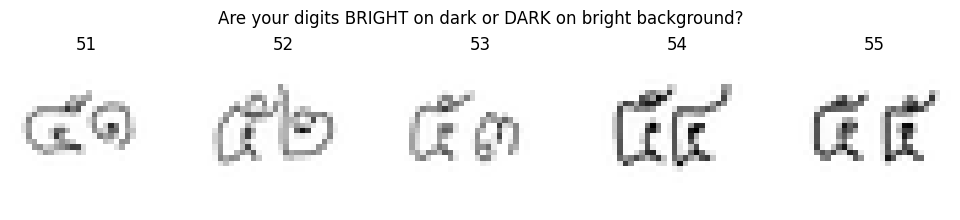

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

# Show one image per class so you can confirm polarity (black-on-white vs white-on-black).
fig, axes = plt.subplots(1, len(idx_to_label), figsize=(2*len(idx_to_label), 2.2))
for ax, cls in zip(axes, idx_to_label):
    sample_path = next(p for p, y in full_train.samples if idx_to_label[y] == cls)
    img = Image.open(sample_path).convert('L').resize((28, 28))
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(cls); ax.axis('off')
plt.suptitle('Are your digits BRIGHT on dark or DARK on bright background?')
plt.tight_layout(); plt.show()


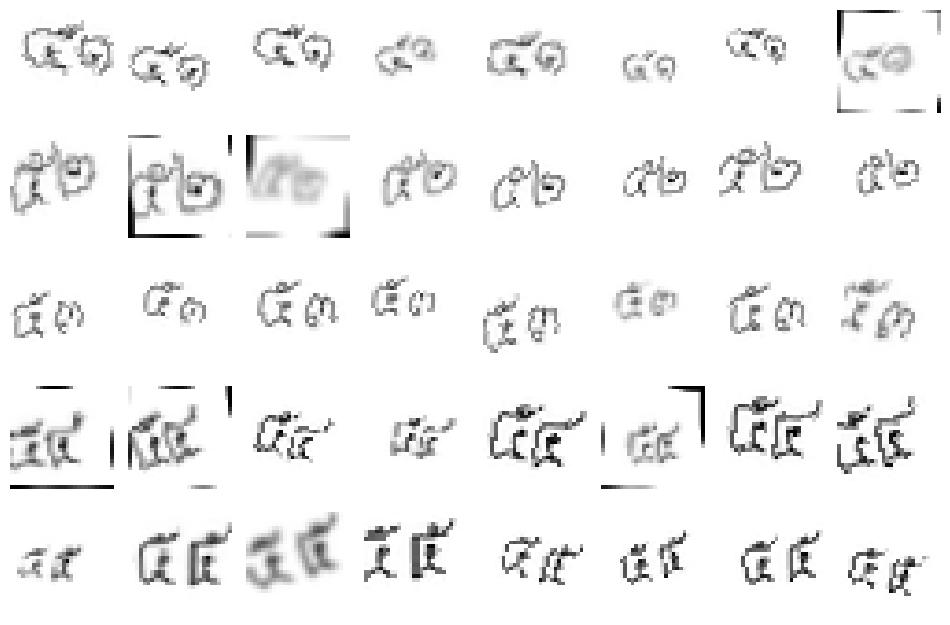

In [22]:
import matplotlib.pyplot as plt
from PIL import Image

N_VARIANTS = 8
fig, axes = plt.subplots(len(idx_to_label), N_VARIANTS, figsize=(N_VARIANTS * 1.2, len(idx_to_label) * 1.3))
for row, cls in enumerate(idx_to_label):
    sample_path = next(p for p, y in full_train.samples if idx_to_label[y] == cls)
    pil = Image.open(sample_path)
    for col in range(N_VARIANTS):
        t = train_tfm(pil)
        img = (t.squeeze(0) * 0.3081 + 0.1307).clamp(0, 1).numpy()
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(cls, rotation=0, labelpad=18, fontsize=12)
plt.tight_layout(); plt.show()

## 4. Model

In [23]:
class DigitCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.20)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.drop2 = nn.Dropout(0.30)
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 28 -> 14
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 14 -> 7
        x = self.drop1(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop2(x)
        return self.fc2(x)

model = DigitCNN(num_classes=len(idx_to_label)).to(device)
print(model)

DigitCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


## 5. Train

In [24]:
opt    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
lossfn = nn.CrossEntropyLoss()    # no label smoothing — let the model be confident

def run_epoch(loader, train):
    model.train(train)
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.set_grad_enabled(train):
            logits = model(x)
            loss   = lossfn(logits, y)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
        loss_sum += loss.item() * x.size(0)
        correct  += (logits.argmax(1) == y).sum().item()
        total    += x.size(0)
    return loss_sum / total, correct / total

best_acc = 0.0
history  = []
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_dl, train=True)
    va_loss, va_acc = run_epoch(val_dl,   train=False)
    sched.step()
    history.append((epoch, tr_loss, tr_acc, va_loss, va_acc))
    flag = ''
    if va_acc > best_acc:
        best_acc = va_acc
        torch.save(model.state_dict(), 'best.pt')
        flag = '  <-- best'
    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS or flag:
        print(f'epoch {epoch:02d}  train {tr_loss:.4f}/{tr_acc:.3f}   val {va_loss:.4f}/{va_acc:.3f}{flag}')

print(f'best val acc: {best_acc:.3f}')


epoch 01  train 1.7485/0.259   val 1.5635/0.320  <-- best
epoch 02  train 1.5304/0.304   val 1.4313/0.533  <-- best
epoch 04  train 1.3229/0.424   val 1.1052/0.667  <-- best
epoch 05  train 1.3005/0.428   val 0.9769/0.613
epoch 10  train 1.0909/0.520   val 0.8030/0.667
epoch 11  train 0.9990/0.605   val 0.7325/0.747  <-- best
epoch 12  train 0.9790/0.605   val 0.6624/0.787  <-- best
epoch 13  train 1.0139/0.565   val 0.6126/0.813  <-- best
epoch 15  train 0.8429/0.640   val 0.5011/0.853  <-- best
epoch 17  train 0.8281/0.642   val 0.4265/0.880  <-- best
epoch 18  train 0.7895/0.678   val 0.4599/0.893  <-- best
epoch 20  train 0.7823/0.687   val 0.3956/0.813
epoch 23  train 0.6718/0.736   val 0.2388/0.973  <-- best
epoch 24  train 0.6878/0.732   val 0.2316/0.987  <-- best
epoch 25  train 0.5930/0.769   val 0.1858/0.973
epoch 30  train 0.5279/0.788   val 0.1463/0.973
epoch 31  train 0.5917/0.755   val 0.1156/1.000  <-- best
epoch 35  train 0.4376/0.826   val 0.1055/0.987
epoch 40  train 

## 5b. Evaluation: accuracy, precision, recall, F1, confusion matrix

Loads the best checkpoint, runs it over the validation set, and reports per-class + macro metrics.

In [25]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)

model.load_state_dict(torch.load('best.pt', map_location=device))
model.eval()

all_y, all_p = [], []
with torch.no_grad():
    for x, y in val_dl:
        x = x.to(device)
        pred = model(x).argmax(1).cpu().numpy()
        all_y.extend(y.numpy()); all_p.extend(pred)
all_y = np.array(all_y); all_p = np.array(all_p)

acc = accuracy_score(all_y, all_p)
prec_macro = precision_score(all_y, all_p, average='macro', zero_division=0)
rec_macro  = recall_score(all_y, all_p,    average='macro', zero_division=0)
f1_macro   = f1_score(all_y, all_p,        average='macro', zero_division=0)

print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec_macro:.4f}  (macro)')
print(f'Recall   : {rec_macro:.4f}  (macro)')
print(f'F1-score : {f1_macro:.4f}  (macro)\n')

print('Per-class report:')
print(classification_report(all_y, all_p, target_names=idx_to_label, zero_division=0, digits=4))

cm = confusion_matrix(all_y, all_p)
print('Confusion matrix (rows = true, cols = pred):')
header = '       ' + '  '.join(f'{c:>4}' for c in idx_to_label)
print(header)
for i, row in enumerate(cm):
    print(f'  {idx_to_label[i]:>3}  ' + '  '.join(f'{v:>4d}' for v in row))

Accuracy : 1.0000
Precision: 1.0000  (macro)
Recall   : 1.0000  (macro)
F1-score : 1.0000  (macro)

Per-class report:
              precision    recall  f1-score   support

          51     1.0000    1.0000    1.0000        11
          52     1.0000    1.0000    1.0000        14
          53     1.0000    1.0000    1.0000        19
          54     1.0000    1.0000    1.0000        18
          55     1.0000    1.0000    1.0000        13

    accuracy                         1.0000        75
   macro avg     1.0000    1.0000    1.0000        75
weighted avg     1.0000    1.0000    1.0000        75

Confusion matrix (rows = true, cols = pred):
         51    52    53    54    55
   51    11     0     0     0     0
   52     0    14     0     0     0
   53     0     0    19     0     0
   54     0     0     0    18     0
   55     0     0     0     0    13


## 6. Save as `.safetensors`

In [ ]:
from safetensors.torch import save_file
import json

model.load_state_dict(torch.load('best.pt', map_location=device))
model.eval()

state = {k: v.contiguous().cpu() for k, v in model.state_dict().items()}
metadata = {
    'classes': json.dumps(idx_to_label),
    'input':   '1x28x28 grayscale, normalize mean=0.1307 std=0.3081',
    'arch':    'DigitCNN: Conv(1,32)->Pool->Conv(32,64)->Pool->FC(3136,128)->FC(128,5)',
}
save_file(state, 'model.safetensors', metadata=metadata)

with open('classes.json', 'w') as f:
    json.dump(idx_to_label, f)

from google.colab import files as gfiles
gfiles.download('model.safetensors')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Quick sanity check

In [27]:
from safetensors.torch import load_file

m2 = DigitCNN(num_classes=len(idx_to_label)).to(device)
m2.load_state_dict(load_file('model.safetensors'))
m2.eval()

x, y = next(iter(val_dl))
x = x.to(device)
with torch.no_grad():
    pred = m2(x).argmax(1).cpu()
print('true :', [idx_to_label[i] for i in y[:16].tolist()])
print('pred :', [idx_to_label[i] for i in pred[:16].tolist()])

true : ['53', '51', '55', '52', '55', '52', '55', '51', '53', '54', '54', '53', '55', '52', '52', '53']
pred : ['53', '51', '55', '52', '55', '52', '55', '51', '53', '54', '54', '53', '55', '52', '52', '53']
